In [2]:
from typing import Dict , TypedDict
from langgraph.graph import StateGraph
#framework that helps you design and manage the flow of tasks in your application using a graph data strcutre 

In [3]:
class AgentState(TypedDict):#Our state schema
    message: str

def greeting_node(state: AgentState) -> AgentState:
    #Docstrings tells llms what the nodes actually does 
    """Simple node that adda greeting message to the state"""

    state['message'] = "Hey" + state['message'] + ', how is your day is going'

    return state 

In [4]:
#Creating graph 

graph = StateGraph(AgentState)
graph.add_node("greeter", greeting_node) #adding the greeting function to the graph
graph.set_entry_point("greeter") #setting the entry point of the graph to the greeter node 
graph.set_finish_point("greeter")

app = graph.compile()


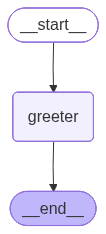

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
obj = AgentState(message="Bob")
result = app.invoke(obj)
#or result = app.invoke({"message" : "Bob"})
# You are passing the initial state object to the graph to start execution.

In [8]:
result['message']

'HeyBob, how is your day is going'